In [189]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
from collections import defaultdict
from scipy import stats

In [190]:
# reading dataset
train_df = pd.read_csv('../../train_classification.csv', index_col=0)
val_df = pd.read_csv('../../validation_classification.csv', index_col=0)
test_df = pd.read_csv('../../test_classification.csv', index_col=0)

In [191]:

functional_lens = []
# taking lengths of function sequences
for i, row in test_df.iterrows():
    if row['non-functional'] is False:
        functional_lens.append(len(row['sequence']))

unique_lengths, counts = np.unique(functional_lens, return_counts=True)
probs = counts / counts.sum()
func_length_dist = {
    'lengths': unique_lengths.tolist(),
    'probs': probs.tolist()
}

In [192]:
def get_non_functional_subsequences(non_functional_sequences, functional_len_distribution):
    def _sample_length_from_func_dist(functional_len_distribution):
        """Sample a length from the functional peptide length distribution."""
        return np.random.choice(
            functional_len_distribution['lengths'],
            p=functional_len_distribution['probs']
        )
    def _get_substring(seq, target_length):
        """Extract a random continuous substring of target_length from seq."""
        seq_len = len(seq)
        if seq_len <= target_length:
            return seq
        start = random.randint(0, seq_len - target_length)
        return seq[start:start + target_length]

    non_func_substrings = []
    for seq in non_functional_sequences:
        target_len = _sample_length_from_func_dist(functional_len_distribution)
        non_func_substrings.append(_get_substring(seq, target_len))

    return non_func_substrings



In [193]:
import random


def generate_length_stratified_subsequences(
    non_functional_sequences,
    min_length=10,
    max_length=100,
    seed=42
):
    """
    Generate one random contiguous subsequence from each source sequence.

    For each source sequence:
      1. Randomly select a target length uniformly from [min_length, max_length],
         restricted to lengths <= source sequence length.
      2. Extract one random contiguous subsequence of that length.

    Parameters
    ----------
    non_functional_sequences : list[str]
        List of non-functional/source protein sequences.

    min_length : int, default=10
        Minimum target subsequence length.

    max_length : int, default=100
        Maximum target subsequence length.

    seed : int or None, default=42
        Random seed for reproducibility.

    Returns
    -------
    subsequences : list[str]
        Generated subsequences.

    lengths : list[int]
        Length of each generated subsequence.

    source_indices : list[int]
        Index of the source sequence from which each subsequence was generated.
    """

    rng = random.Random(seed)

    subsequences = []
    lengths = []
    source_indices = []

    for idx, seq in enumerate(non_functional_sequences):

        # Clean sequence
        seq = str(seq).strip()

        # Skip sequences shorter than the minimum length
        if len(seq) < min_length:
            continue

        # Maximum possible target length for this sequence
        available_max = min(len(seq), max_length)

        # Randomly select target length
        target_length = rng.randint(min_length, available_max)

        # Randomly select starting position
        start = rng.randint(0, len(seq) - target_length)

        # Extract contiguous subsequence
        subseq = seq[start:start + target_length]

        subsequences.append(subseq)
        lengths.append(target_length)
        source_indices.append(idx)

    return subsequences, lengths, source_indices

In [194]:

non_func = test_df[test_df['non-functional']]['sequence'].tolist()


pseudo_non_func, _, non_func_idxs = generate_length_stratified_subsequences(non_func)


In [195]:
len(pseudo_non_func)

32726

<Axes: ylabel='Count'>

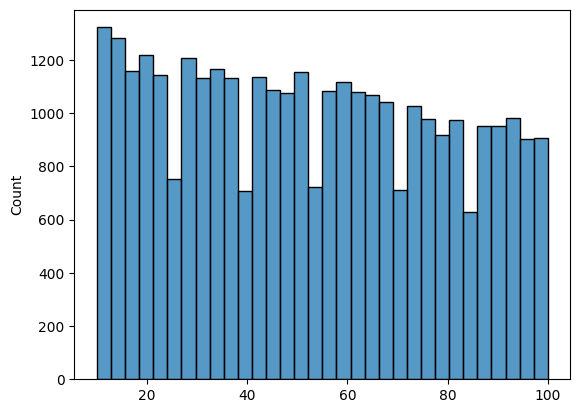

In [36]:
sns.histplot([len(s) for s in pseudo_non_func])

In [ ]:
# macrel peptides --fasta pseudo_nonfunc_peptides.faa --output macrel_peptides

In [196]:
pseudo_non_func = []
with open("pseudo_nonfunc_peptides.faa") as f:
    for l in f.readlines():
        l = l.strip()
        if len(l)>0 and l.startswith('>peptide') is False:
            pseudo_non_func.append(l)

# macrel

In [85]:
with open("pseudo_nonfunc_peptides.faa", "w") as f:
    for idx, seq in enumerate(pseudo_non_func, start=1):
        f.write(f">peptide_{idx}\n{seq}\n")

In [198]:
with open("out_peptides/macrel.out.prediction") as f: # this file do not have negatives
    pseudo_macrel_amp = []
    pseudo_macrel_lenth_prob = defaultdict(list)
    for l in f.readlines():
        if l.startswith('peptide'):
            pseudo_macrel_amp.append(l.split('\t')[1])
            pseudo_macrel_lenth_prob[len(l.split('\t')[1])].append(float(l.split('\t')[3]))

In [199]:
len(pseudo_macrel_amp)

623

# pepmtl

In [202]:
# --------------------------------------------------
# 1. Imports (add these to the existing ones)
# --------------------------------------------------
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import itertools
from torchvision.transforms import Resize
from ast import literal_eval
from sklearn.metrics import matthews_corrcoef
from torchvision import models
from transformers import AutoTokenizer, AutoModelForMaskedLM
import math
import json
from collections import defaultdict
import seaborn as sns
from matplotlib.colors import LogNorm
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
# --------------------------------------------------

In [203]:


class ESM2_Encoder(nn.Module):
    def __init__(self, model_name, trainable=True, unfreeze_last_n=0):
        super().__init__()
        self.esm_mlm = AutoModelForMaskedLM.from_pretrained(model_name)
        self.hidden_size = self.esm_mlm.config.hidden_size
        if not trainable:
            for param in self.esm_mlm.parameters():
                param.requires_grad = False
            if unfreeze_last_n > 0:
                for layer in self.esm_mlm.esm.encoder.layer[-unfreeze_last_n:]:
                    for param in layer.parameters():
                        param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        return self.esm_mlm.esm(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state

class SEBlock(nn.Module):
    """
    Mask-aware Squeeze-and-Excitation block.

    Input:
        x        : [B, C, L]
        seq_mask : [B, L], 1 for valid tokens, 0 for PAD

    The channel descriptor is computed using only valid sequence positions.
    """

    def __init__(self, channels, reduction=4):
        super().__init__()

        hidden = max(channels // reduction, 1)

        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )

    def forward(self, x, seq_mask):
        # [B, L] -> [B, 1, L]
        mask = seq_mask.unsqueeze(1).to(dtype=x.dtype)

        # Remove PAD contributions
        x_masked = x * mask

        # Number of valid positions per sequence
        lengths = seq_mask.sum(
            dim=1,
            keepdim=True
        ).clamp_min(1).to(dtype=x.dtype)

        # Masked global average pooling over sequence dimension
        # [B, C, L] -> [B, C]
        channel_descriptor = (
            x_masked.sum(dim=-1) / lengths
        )

        # Channel-wise gates
        gates = self.fc(channel_descriptor).unsqueeze(-1)

        # Apply channel recalibration
        return x * gates

class ConvBlock(nn.Module):
    """
    Mask-aware two-layer 1D convolution block.

    Uses LayerNorm instead of BatchNorm so that padded positions
    do not participate in batch/sequence normalization statistics.
    """

    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=False
        )

        self.norm1 = nn.LayerNorm(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=False
        )

        self.norm2 = nn.LayerNorm(out_channels)

    @staticmethod
    def apply_layernorm(x, norm):
        """
        Conv output: [B, C, L]
        LayerNorm expects normalized dimension at the end.
        """
        x = x.transpose(1, 2)      # [B, L, C]
        x = norm(x)
        x = x.transpose(1, 2)      # [B, C, L]
        return x

    def forward(self, x, mask):
        """
        x    : [B, C, L]
        mask : [B, 1, L]
        """
        # First convolution
        y = self.conv1(x)
        y = self.apply_layernorm(
            y,
            self.norm1
        )

        y = F.gelu(y)

        # Explicitly remove PAD activations
        y = y * mask

        # Second convolution
        y = self.conv2(y)

        y = self.apply_layernorm(
            y,
            self.norm2
        )

        y = F.gelu(y)

        # Explicitly remove PAD activations again
        y = y * mask

        return y

class EnhancedCNN1D(nn.Module):
    """
    Mask-aware multi-scale CNN for peptide/protein sequences.

    Branches:
        kernel 3 -> effective receptive field 5
        kernel 5 -> effective receptive field 9
        kernel 7 -> effective receptive field 13

    Each branch contains two convolutional layers.

    Output:
        [B, 2 * 3 * conv_dim]

    For conv_dim=128:
        output = [B, 768]
    """

    def __init__(
        self,
        vocab_size=33,
        embed_dim=128,
        conv_dim=128
    ):
        super().__init__()


        # Token embedding
        self.embed = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=1 # ESM TOKENIZER
        )

        # Multi-scale CNN branches
        self.branches = nn.ModuleList([
            ConvBlock(
                in_channels=embed_dim,
                out_channels=conv_dim,
                kernel_size=k
            )
            for k in [3, 5, 7]
        ])

        # Residual projection
        self.res_proj = nn.Conv1d(
            embed_dim,
            conv_dim,
            kernel_size=1,
            bias=False
        )

        # Squeeze-and-Excitation
        self.se = SEBlock(
            channels=conv_dim * 3,
            reduction=4
        )

        self.dropout = nn.Dropout(0.2)

        # Three branches × conv_dim channels
        # Max pooling + mean pooling
        self.hidden_size = conv_dim * 3 * 2

    def forward(self, x, seq_mask):
        """
        Args:
            x:
                [B, L] token IDs

            seq_mask:
                [B, L]
                1 = valid token
                0 = PAD
        Returns:
            CNN feature vector:
                [B, hidden_size]

        For conv_dim=128:
            [B, 768]
        """


        # Validate mask


        if seq_mask is None:
            raise ValueError(
                "seq_mask must be provided to EnhancedCNN1D. "
                "CNN padding masking must never be bypassed."
            )
        # Embedding
        # [B, L] -> [B, L, embed_dim]
        x = self.embed(x)

        # [B, L, embed_dim] -> [B, embed_dim, L]
        x = x.transpose(1, 2)

        # [B, L] -> [B, 1, L]
        mask = seq_mask.unsqueeze(1).to(dtype=x.dtype)

        # Explicitly zero PAD embeddings
        x = x * mask

        # Residual pathway
        res = self.res_proj(x)

        # Remove PAD activations
        res = res * mask

        # Multi-scale branches
        outs = []

        for branch in self.branches:
            y = branch(x, mask)
            # Residual connection
            y = y + res
            # Guarantee PAD = 0 after residual addition
            y = y * mask
            outs.append(y)

        # Concatenate branches
        # [B, 128*3, L]
        combined = torch.cat(
            outs,
            dim=1
        )

        # Guarantee no PAD signal
        combined = combined * mask

        # Mask-aware SE
        combined = self.se(
            combined,
            seq_mask
        )

        # SE can theoretically produce nonzero values
        # at PAD positions, so mask once more.
        combined = combined * mask

        # MASKED GLOBAL MAX POOLING
        # PAD cannot become the maximum.
        combined_for_max = combined.masked_fill(
            seq_mask.unsqueeze(1) == 0,
            torch.finfo(combined.dtype).min
        )

        max_pooled = combined_for_max.max(
            dim=-1
        ).values


        # MASKED GLOBAL MEAN POOLING
        combined_for_mean = combined * mask

        # Actual number of valid tokens
        lengths = seq_mask.sum(
            dim=1,
            keepdim=True
        ).clamp_min(1).to(
            dtype=combined.dtype
        )

        mean_pooled = (
            combined_for_mean.sum(dim=-1)
            / lengths
        )

        # FINAL REPRESENTATION
        pooled = torch.cat(
            [
                max_pooled,
                mean_pooled
            ],
            dim=1
        )

        return self.dropout(pooled)


class MultiHeadAttentionPool(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.attn = nn.Sequential(
            nn.Linear(dim, 128), 
            nn.Tanh(), 
            nn.Linear(128, num_heads)
        )
        self._last_weights = None

    def forward(self, x, mask):
        scores = self.attn(x)
        scores = scores.masked_fill(mask.unsqueeze(-1) == 0, -1e4)
        weights = torch.softmax(scores, dim=1)
        self._last_weights = weights
        pooled = (x.unsqueeze(2) * weights.unsqueeze(-1)).sum(dim=1)
        return pooled.view(x.size(0), -1)


    def orthogonality_loss(self):
        """Penalize overlap between head attention distributions."""
        if self._last_weights is None:
            return 0.0
            
        # weights: [B, L, num_heads] -> transpose to [B, num_heads, L]
        w = self._last_weights.transpose(1, 2)  
        
        # Gram matrix of head attention distributions: shape [B, num_heads, num_heads]
        gram = torch.bmm(w, w.transpose(1, 2))  
        
        # Create a boolean mask for the off-diagonal elements (~torch.eye inverts the identity matrix)
        mask = ~torch.eye(self.num_heads, dtype=torch.bool, device=gram.device)
        
        # Penalize only the off-diagonal overlap to encourage heads to focus on different tokens.
        # We want these dot products to be pushed towards 0.
        loss = (gram[:, mask] ** 2).mean()
        
        return loss
    
class GatedFusion(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(input_dim, input_dim), nn.Sigmoid())
    def forward(self, x):
        return x * self.gate(x)

class PeptideNetwork(nn.Module):
    def __init__(self, num_classes=21, mask_token_id=32):
        super().__init__()
        self.mask_token_id = mask_token_id
        self.num_classes = num_classes

        # BOTH encoders are now the 8M parameter t6 model
        self.esm_t6_a = ESM2_Encoder("facebook/esm2_t6_8M_UR50D", trainable=True)        
        self.esm_t6_b = ESM2_Encoder("facebook/esm2_t6_8M_UR50D", trainable=False, unfreeze_last_n=2)                                  
        self.cnn = EnhancedCNN1D()          # Bx768

        # REDUCED cross_dim to 128 to save parameters
        cross_dim = 128
        self.proj_t6_a = nn.Linear(320, cross_dim)
        self.proj_t6_b = nn.Linear(320, cross_dim) # Updated to 320 for t6

        self.cross_t6_a = nn.MultiheadAttention(cross_dim, num_heads=4, batch_first=True, dropout=0.1)
        self.ln_ca_t6_a = nn.LayerNorm(cross_dim)
        
        self.cross_t6_b = nn.MultiheadAttention(cross_dim, num_heads=4, batch_first=True, dropout=0.1)
        self.ln_ca_t6_b = nn.LayerNorm(cross_dim)
        
        self.pool_t6_a = MultiHeadAttentionPool(cross_dim, num_heads=4)
        self.pool_t6_b = MultiHeadAttentionPool(cross_dim, num_heads=4)

        # Bottleneck reduction layer before fusion
        # Concat size: 128*4*3 (pools) + 768 (CNN) = 1536 + 768 = 2304
        concat_size = cross_dim * 4 * 2 + self.cnn.hidden_size
        
        self.dim_reduce = nn.Sequential(
            nn.Linear(concat_size, 512),
            nn.GELU()
        )
        
        # Fusion now operates efficiently on 512 dimensions
        self.fusion = GatedFusion(512)
        self.ln = nn.LayerNorm(512)

        # binary head
        binary_features_dim = 64
        self.binary_features = nn.Sequential(
            nn.Linear(512, binary_features_dim),
            nn.GELU(),
            nn.Dropout(0.2)
        )
        self.binary_classifier = nn.Linear(64, 1) # Final logit

        # Task Query Decoder
        self.task_dim = 128
        self.n_memory_tokens = 16
        self.memory_proj = nn.Sequential(
            nn.Linear(512 + binary_features_dim, self.task_dim * self.n_memory_tokens),
            nn.GELU(),
        )
        self.task_queries = nn.Embedding(num_classes, self.task_dim)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=self.task_dim, nhead=4, dim_feedforward=256,
            batch_first=True, dropout=0.1
        )
        self.task_decoder = nn.TransformerDecoder(decoder_layer, num_layers=2)
        self.task_classifiers = nn.ModuleList([
            nn.Linear(self.task_dim, 1) for _ in range(num_classes)
        ])

    def _mask_tokens(self, input_ids, attention_mask, mask_prob=0.15):
        masked_ids = input_ids.clone()
        prob_matrix = torch.full_like(input_ids, mask_prob, dtype=torch.float)
        prob_matrix[attention_mask == 0] = 0
        prob_matrix[:, 0] = 0
        seq_lens = attention_mask.sum(dim=1)
        for i in range(len(seq_lens)):
            if seq_lens[i] > 1:
                prob_matrix[i, seq_lens[i] - 1] = 0
        mask = torch.bernoulli(prob_matrix).bool()
        masked_ids[mask] = self.mask_token_id
        return masked_ids

    def _extract_features(self, seq_input, seq_mask):
        esm6_a_seq = self.esm_t6_a(seq_input, seq_mask)       
        esm6_b_seq = self.esm_t6_b(seq_input, seq_mask)     
        cnn_feat = self.cnn(seq_input, seq_mask)                            

        t6_a = self.proj_t6_a(esm6_a_seq)       
        t6_b = self.proj_t6_b(esm6_b_seq)    


        kv_pad = seq_mask == 0  

        ca_t6_a, _ = self.cross_t6_a(t6_a, t6_b, t6_b, key_padding_mask=kv_pad)
        ca_t6_a = self.ln_ca_t6_a(t6_a + ca_t6_a)

        ca_t6_b, _ = self.cross_t6_b(t6_b, t6_a, t6_a, key_padding_mask=kv_pad)
        ca_t6_b = self.ln_ca_t6_b(t6_b + ca_t6_b)

        pooled_t6_a = self.pool_t6_a(ca_t6_a, seq_mask)
        pooled_t6_b = self.pool_t6_b(ca_t6_b, seq_mask)

        # Concat -> Reduce -> Fuse
        combined = torch.cat([pooled_t6_a, pooled_t6_b, cnn_feat], dim=1)  
        reduced = self.dim_reduce(combined)
        fusion = self.ln(reduced + self.fusion(reduced))

        binary_features = self.binary_features(fusion)
        
        return binary_features, torch.cat([fusion, binary_features], dim=1)
    
    def _binary_classify(self, binary_features):
        
        binary_logits = self.binary_classifier(binary_features)

        return binary_logits

    def _classify(self, final_fusion):
        B = final_fusion.size(0)
        memory = self.memory_proj(final_fusion).view(B, self.n_memory_tokens, self.task_dim)
        tgt = self.task_queries.weight.unsqueeze(0).expand(B, -1, -1)
        decoded = self.task_decoder(tgt, memory)
        logits = torch.cat([self.task_classifiers[i](decoded[:, i, :])
                           for i in range(self.num_classes)], dim=1)
        return logits

    def forward(self, seq_input, seq_mask, mask_tokens=False):
        if mask_tokens and self.training:
            seq_input = self._mask_tokens(seq_input, seq_mask)
        
        binary_features, combined_features = self._extract_features(seq_input, seq_mask)
        

        return self._binary_classify(binary_features), self._classify(combined_features)


    def ortho_loss(self):
        return (self.pool_t6_a.orthogonality_loss() +
                self.pool_t6_b.orthogonality_loss() 
                ) / 2
    
    def get_features(self, seq_input, seq_mask, mask_tokens=False):
        if mask_tokens and self.training:
            seq_input = self._mask_tokens(seq_input, seq_mask)
        return self._extract_features(seq_input, seq_mask)

    def multi_classify(self, combined):
        return self._classify(combined)
    
    def binary_classify(self, binary_features):
        return self._binary_classify(binary_features)



In [209]:
# loading classification model
MODEL_PATH = '../../phase_2_model.pt'
THRESHOLD_PATH = '../../phase_2_model.json'
DEVICE = 'cuda:1'

model = PeptideNetwork(num_classes=13, mask_token_id=32)
if os.path.exists(MODEL_PATH):
    print(f"Found {MODEL_PATH} ! Loading weights.")
    state_dict = torch.load(MODEL_PATH, map_location="cpu")
else:
    raise("Wrong model path")

esm_tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
model.load_state_dict(state_dict, strict=True)
model = model.to(DEVICE)


func_names = [
    'anti-bacterial', 'anti-cancer', 'anti-fungal', 'anti-parasitic', 'anti-viral', 
    'cell-cell-communication', 'drug-delivery', 'immunological', 'inhibitor', 
    'metabolic', 'other-functional', 'signal-peptide', 'toxic'
]
bin_names = ["NON-FUNCTIONAL"]

# reading threasholds 
with open(THRESHOLD_PATH) as f:
    data = json.load(f)
    best_i = 0
    for i, e in enumerate(data):
        if e['val_avg_func_mcc'] > data[best_i]['val_avg_func_mcc']:
            best_i = i

    print(f'reading thresholds from {best_i}th epoch, as it gave the best val mcc')
    threshold_binary = data[best_i]['thresholds']['binary']
    threshold_functional = data[best_i]['thresholds']['functional']

def enable_dropout(model):
    """
    Specifically tailored for PeptideNetwork to activate all sources of dropout
    during Test-Time Augmentation (TTA), including functional dropouts hidden 
    inside complex PyTorch modules.
    """
    for module in model.modules():
        class_name = module.__class__.__name__
        
        # 1. Standard explicit dropout layers (Dropout, Dropout1d, Dropout2d)
        if class_name.startswith('Dropout'):
            module.train()
            
        # 2. Cross-Attention functional dropout
        elif class_name == 'MultiheadAttention':
            module.train()
            
        # 3. Task Query Decoder functional dropout
        elif class_name in ['TransformerDecoder', 'TransformerDecoderLayer']:
            module.train()
            
        # 4. GRU functional dropout (applied between internal layers)
        elif class_name == 'GRU':
            module.train()

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

Found ../../phase_2_model.pt ! Loading weights.
reading thresholds from 21th epoch, as it gave the best val mcc


In [210]:
BATCH_SIZE = 256
TTA_PASSES = 5


In [207]:
def inference(model, sequences):
    test_tta_bin_preds = [[] for _ in range(TTA_PASSES)]
    test_tta_spec_preds = [[] for _ in range(TTA_PASSES)]

    with torch.no_grad():
        model.eval()
        for i in range(0, len(sequences), BATCH_SIZE):
            batch = sequences[i: i+BATCH_SIZE]
            
            # FIX: Tokenize the 'batch', not the entire 'sequences' list!
            encodings = esm_tokenizer(batch, add_special_tokens=True, max_length=100,
                                        padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt')

            input_ids = encodings['input_ids'].to(DEVICE)
            attention_mask = encodings['attention_mask'].to(DEVICE)


            pred_bin, pred_spec = model(input_ids, attention_mask)

            # First pass predictions
            test_tta_bin_preds[0].append(torch.sigmoid(pred_bin).detach().cpu().numpy())
            test_tta_spec_preds[0].append(torch.sigmoid(pred_spec).detach().cpu().numpy())

            # Additional TTA passes
            if TTA_PASSES > 1:
                enable_dropout(model)
                for t in range(1, TTA_PASSES):
                    pred_bin_t, pred_spec_t = model(input_ids, attention_mask)
                    test_tta_bin_preds[t].append(torch.sigmoid(pred_bin_t).detach().cpu().numpy())
                    test_tta_spec_preds[t].append(torch.sigmoid(pred_spec_t).detach().cpu().numpy())
                model.eval()

        y_pred_bin_test = np.mean([np.concatenate(pred_list) for pred_list in test_tta_bin_preds], axis=0)

        raw_pred_spec_test = np.mean([np.concatenate(pred_list) for pred_list in test_tta_spec_preds], axis=0)

        # SOFT GATING for Test
        y_pred_spec_test = raw_pred_spec_test * (1 - y_pred_bin_test)

        return y_pred_bin_test, y_pred_spec_test


In [208]:
print(MODEL_PATH)
bin_probs_phase_1_pseudo, multi_probs_phase_1_pseudo = inference(model, list(pseudo_non_func))

../../phase_1_model.pt


In [211]:
print(MODEL_PATH)
bin_probs_phase_2_pseudo, multi_probs_phase_2_pseudo = inference(model, list(pseudo_non_func))

../../phase_2_model.pt


In [212]:
[
    'anti-bacterial', 'anti-cancer', 'anti-fungal', 'anti-parasitic', 'anti-viral', 
    'cell-cell-communication', 'drug-delivery', 'immunological', 'inhibitor', 
    'metabolic', 'other-functional', 'signal-peptide', 'toxic'
]

['anti-bacterial',
 'anti-cancer',
 'anti-fungal',
 'anti-parasitic',
 'anti-viral',
 'cell-cell-communication',
 'drug-delivery',
 'immunological',
 'inhibitor',
 'metabolic',
 'other-functional',
 'signal-peptide',
 'toxic']

In [213]:
pseudo_phase_1_functional = [] # peptides
pseudo_phase_1_amp = []
pseudo_phase_2_functional = []
pseudo_phase_2_amp = []

for i in range(len(bin_probs_phase_1_pseudo)):
    is_fun = False

    if bin_probs_phase_1_pseudo[i][0] < threshold_binary:
        is_fun = True

    if is_fun:
        pseudo_phase_1_functional.append(pseudo_non_func[i])

for i in range(len(multi_probs_phase_1_pseudo)):
    is_amp = False
    for j in [0, 2, 3, 4]:
        if multi_probs_phase_1_pseudo[i][j] >= threshold_functional[j]:
            is_amp = True

    if is_amp:
        pseudo_phase_1_amp.append(pseudo_non_func[i])


for i in range(len(multi_probs_phase_2_pseudo)):
    is_fun = False
    if bin_probs_phase_2_pseudo[i][0] < threshold_binary:
            is_fun = True

    if is_fun:
        pseudo_phase_2_functional.append(pseudo_non_func[i])

for i in range(len(multi_probs_phase_2_pseudo)):
    is_amp = False
    for j in [0, 2, 3, 4]:
        if multi_probs_phase_2_pseudo[i][j] >= threshold_functional[j]:
            is_amp = True

    if is_amp:
        pseudo_phase_2_amp.append(pseudo_non_func[i])

In [214]:
print(len(pseudo_phase_1_functional), len(pseudo_phase_1_amp), len(pseudo_phase_2_functional), len(pseudo_phase_2_amp))

17812 7028 1728 292


# for mcmfpp

In [62]:
with open("../mcmfpp/MCMFPP/nonfunc_peptides.faa", "w") as f:
    for idx, seq in enumerate(non_func):
        seq = seq.upper()
        f.write(f">000000000000000000000\n{seq}\n")

In [215]:
with open("../mcmfpp/MCMFPP/pseudo_nonfunc_peptides.faa", "w") as f:
    for idx, seq in enumerate(pseudo_non_func):
        seq = seq.upper()
        f.write(f">000000000000000000000\n{seq}\n")

In [216]:
amp_cols = [
    'ABP', 'ACVP', 'AEP', 'AHIVP', 'AMRSAP', 'APP', 'ATP', 'AVP'
]

In [217]:
pseudo_mcm_functional = []
pseudo_mcm_amp = []

with open("../mcmfpp/MCMFPP/mcmfpp_pseudo_output.txt", "r") as f:
    lines = f.readlines()
    l_idx = 0
    while l_idx < len(lines):
        if lines[l_idx].startswith('>'):
            # remove the leading '>' from the header line
            seq = lines[l_idx].strip().lstrip('>').strip()

            if l_idx + 1 < len(lines) and len(lines[l_idx + 1].strip()) > 0:
                classes = [c.strip() for c in lines[l_idx + 1].strip().split(',')]
                pseudo_mcm_functional.append(seq)

                if len(set(amp_cols).intersection(set(classes))) > 0:
                    pseudo_mcm_amp.append(seq)
        l_idx += 1


In [218]:
len(pseudo_mcm_amp)

13401

# comparing an graphs

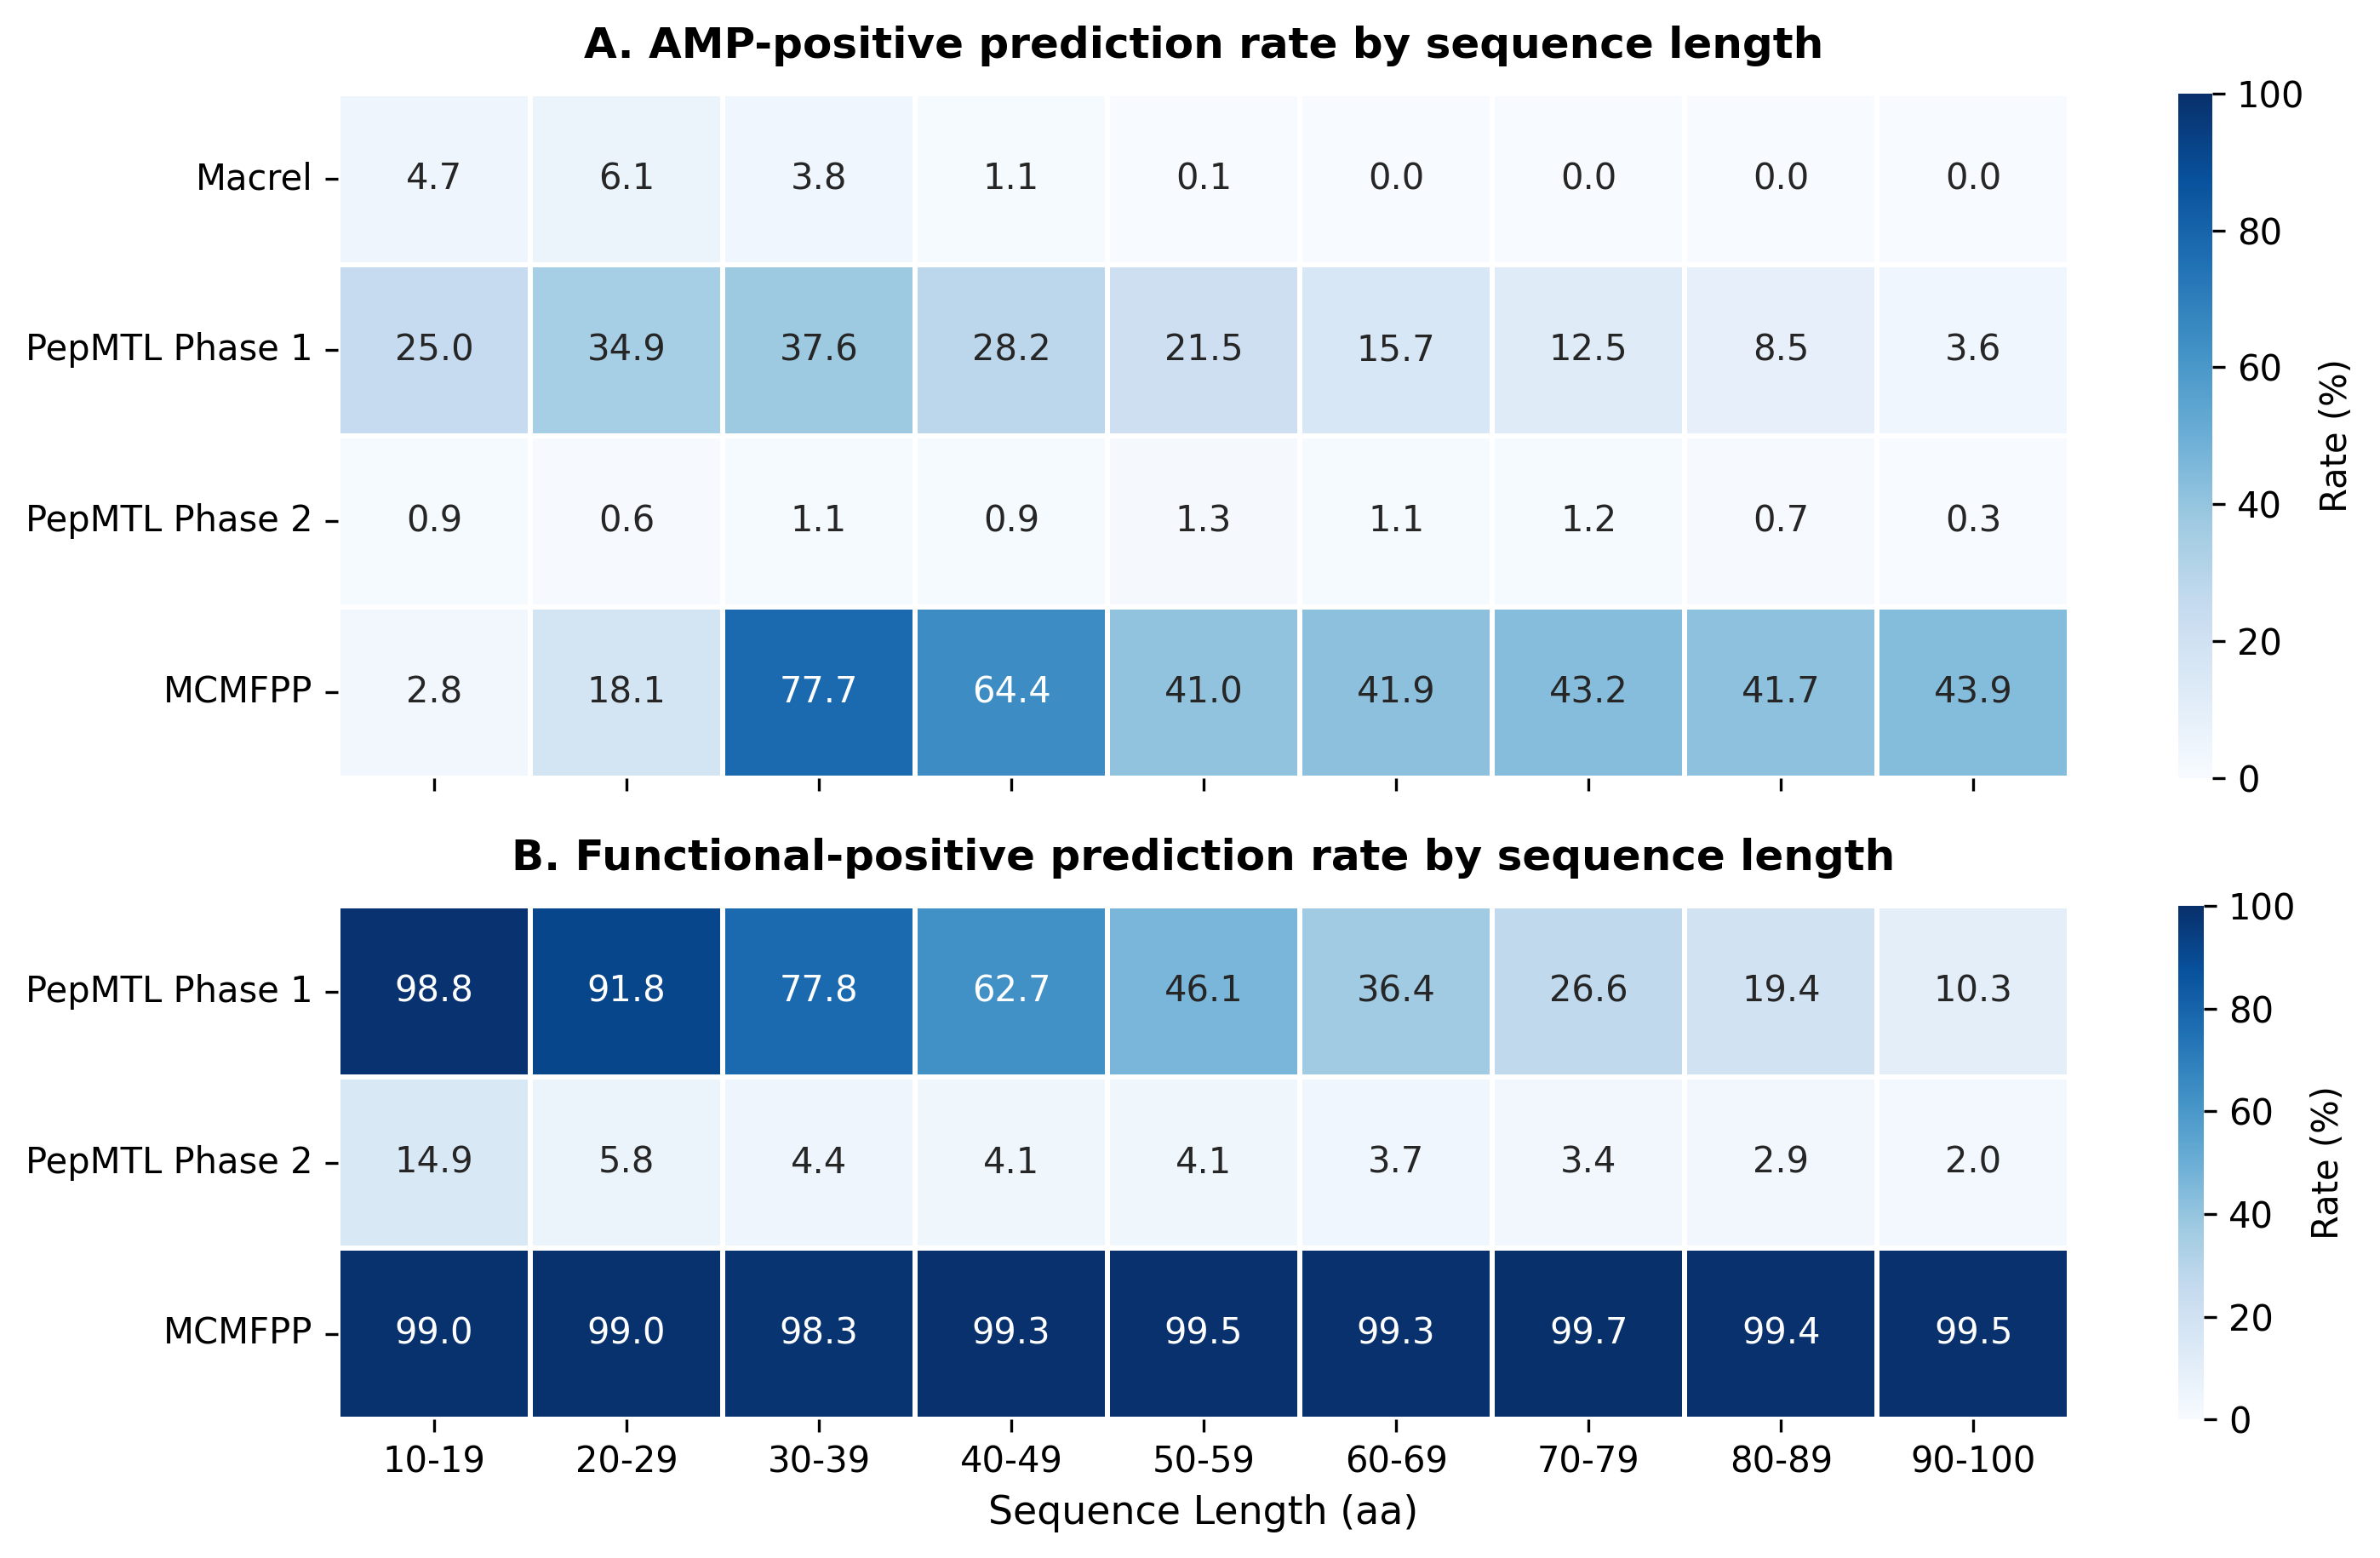

In [224]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


length_bins = [
    (10, 19),
    (20, 29),
    (30, 39),
    (40, 49),
    (50, 59),
    (60, 69),
    (70, 79),
    (80, 89),
    (90, 100)
]

bin_labels = [
    "10-19",
    "20-29",
    "30-39",
    "40-49",
    "50-59",
    "60-69",
    "70-79",
    "80-89",
    "90-100"
]


amp_lists = {
    'Macrel': pseudo_macrel_amp,
    'PepMTL Phase 1': pseudo_phase_1_amp,
    'PepMTL Phase 2': pseudo_phase_2_amp,
    'MCMFPP': pseudo_mcm_amp,
}


# ============================================================
# FIGURE 2 — FUNCTIONAL
# ============================================================

functional_lists = {
    'PepMTL Phase 1': pseudo_phase_1_functional,
    'PepMTL Phase 2': pseudo_phase_2_functional,
    'MCMFPP': pseudo_mcm_functional,
}

def build_rate_dataframe(prediction_dict, background_peptides, length_bins, bin_labels):
    bg_lens = np.array([len(p) for p in background_peptides])
    matrix = []
    
    for name, peptides in prediction_dict.items():
        pred_lens = np.array([len(p) for p in peptides])
        row = []
        for lower, upper in length_bins:
            bg_mask = (bg_lens >= lower) & (bg_lens <= upper)
            pred_mask = (pred_lens >= lower) & (pred_lens <= upper)
            denom = bg_mask.sum()
            num = pred_mask.sum()
            row.append((100.0 * num / denom) if denom > 0 else np.nan)
        matrix.append(row)
        
    return pd.DataFrame(matrix, index=prediction_dict.keys(), columns=bin_labels)

# ------------------------------------------------------------
# Render Two-Panel Heatmap
# ------------------------------------------------------------
df_amp = build_rate_dataframe(amp_lists, pseudo_non_func, length_bins, bin_labels)
df_func = build_rate_dataframe(functional_lists, pseudo_non_func, length_bins, bin_labels)

fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(10, 6.2), 
    gridspec_kw={'height_ratios': [len(df_amp), len(df_func)]},
    dpi=300
)

# Panel 1: AMP
sns.heatmap(
    df_amp, ax=ax1, annot=True, fmt=".1f", cmap="Blues",
    cbar_kws={'label': 'Rate (%)'}, linewidths=1.0, linecolor='white',
    vmin=0, vmax=100
)
ax1.set_title(
    "A. AMP-positive prediction rate by sequence length",
    fontsize=12,
    fontweight='bold',
    pad=10
)
ax1.set_xticklabels([])
ax1.set_xlabel("")

# Panel 2: Functional
sns.heatmap(
    df_func, ax=ax2, annot=True, fmt=".1f", cmap="Blues",
    cbar_kws={'label': 'Rate (%)'}, linewidths=1.0, linecolor='white',
    vmin=0, vmax=100
)

ax2.set_title(
    "B. Functional-positive prediction rate by sequence length",
    fontsize=12,
    fontweight='bold',
    pad=10
)
ax2.set_xlabel("Sequence Length (aa)", fontsize=11)

plt.tight_layout()
plt.savefig('length_bias_heatmap.eps', format='eps', bbox_inches='tight', facecolor='white')

plt.show()